In [1]:
import pandas as pd

df = pd.read_csv("../data/processed_news_nlp.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label"].value_counts())

Dataset shape: (38646, 10)

Columns:
['title', 'text', 'subject', 'date', 'label', 'text_length', 'content', 'clean_text', 'no_stopwords', 'processed_text']

Label distribution:
label
1    21191
0    17455
Name: count, dtype: int64


In [2]:
print(df[["label", "processed_text"]].head(10))

   label                                     processed_text
0      0  ben stein call th circuit court committed coup...
1      1  trump drop steve bannon national security coun...
2      1  puerto rico expects u lift jones act shipping ...
3      0  oops trump accidentally confirmed leaked israe...
4      1  donald trump head scotland reopen golf resort ...
5      0  paul ryan responds dems sitin gun control disg...
6      0  awesome diamond silk rip press dont believe vi...
7      0  stand cheer ukip party leader slam germany fra...
8      1  north korea show sign serious talking u offici...
9      1  trump signal willingness raise u minimum wage ...


In [3]:
print(df["processed_text"].isna().sum())
print(df["processed_text"].str.len().describe())

5
count    38641.000000
mean      1752.711912
std       1341.760013
min         40.000000
25%        968.000000
50%       1576.000000
75%       2182.000000
max      37930.000000
Name: processed_text, dtype: float64


In [4]:
X = df["processed_text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (38646,)
y shape: (38646,)


In [5]:
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 30916
Testing samples: 7730

Training label distribution:
label
1    16952
0    13964
Name: count, dtype: int64

Testing label distribution:
label
1    4239
0    3491
Name: count, dtype: int64


In [6]:
print("Dataset shape:", df.shape)
print("Total labels:", df["label"].value_counts().sum())

Dataset shape: (38646, 10)
Total labels: 38646


In [7]:
X = df["processed_text"].fillna("")
y = df["label"]

print("Before split:")
print("X:", len(X))
print("y:", len(y))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nAfter split:")
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))

print("\nTraining labels:")
print(y_train.value_counts().sort_index())

print("\nTesting labels:")
print(y_test.value_counts().sort_index())

print("\nTotal after split:", len(X_train) + len(X_test))

Before split:
X: 38646
y: 38646

After split:
X_train: 30916
X_test: 7730
y_train: 30916
y_test: 7730

Training labels:
label
0    13964
1    16952
Name: count, dtype: int64

Testing labels:
label
0    3491
1    4239
Name: count, dtype: int64

Total after split: 38646


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

improved_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = improved_tfidf.fit_transform(X_train)
X_test_tfidf = improved_tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (30916, 50000)
Testing TF-IDF shape: (7730, 50000)


In [9]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

improved_svm = LinearSVC(
    C=1.0,
    class_weight=None,
    random_state=42
)

improved_svm.fit(X_train_tfidf, y_train)

y_pred = improved_svm.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Improved Linear SVM Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Improved Linear SVM Accuracy: 0.996248382923674

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      3491
        Real       0.99      1.00      1.00      4239

    accuracy                           1.00      7730
   macro avg       1.00      1.00      1.00      7730
weighted avg       1.00      1.00      1.00      7730


Confusion Matrix:
[[3467   24]
 [   5 4234]]


In [11]:
import pandas as pd

updated_df = pd.read_csv("../test_data/indian_news_test.csv")

print("Indian-news test shape:", updated_df.shape)
print(updated_df[["title", "actual_label"]])

Indian-news test shape: (5, 4)
                                               title  actual_label
0  Students protest against irregularities in Jha...             1
1  NEET UG 2026: MCC extends Round 1 choice-filli...             1
2  Pimpri-Chinchwad residents can report potholes...             1
3  RBI intervenes across markets to steady the rupee             1
4  Milky Mist rises about 30 percent in Indian debut             1


In [12]:
for i, row in updated_df.iterrows():

    article_text = row["text"]

    article_vector = improved_tfidf.transform([article_text])

    prediction = improved_svm.predict(article_vector)[0]

    print(f"\nArticle {i+1}: {row['title']}")
    print("Actual: REAL")
    print("Model:", "REAL" if prediction == 1 else "FAKE")


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model: FAKE

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model: FAKE

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model: FAKE

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model: FAKE

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model: FAKE


In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from app.predictor import predict_news

print("Predictor loaded successfully!")

Predictor loaded successfully!


In [15]:
import inspect

print(inspect.getsource(predict_news))

def predict_news(article):
    # Preprocess the article
    text = clean_text(article)
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    # Convert text to TF-IDF
    article_tfidf = tfidf.transform([text])

    # Predict
    prediction = model.predict(article_tfidf)[0]

    if prediction == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"



In [16]:
# Get the preprocessing functions used by your existing predictor

clean_text = predict_news.__globals__["clean_text"]
remove_stopwords = predict_news.__globals__["remove_stopwords"]
lemmatize_text = predict_news.__globals__["lemmatize_text"]

print("Preprocessing functions loaded successfully!")

Preprocessing functions loaded successfully!


In [17]:
for i, row in updated_df.iterrows():

    # Apply EXACT same preprocessing used by the original model
    text = clean_text(row["text"])
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    # Use the NEW TF-IDF
    article_vector = improved_tfidf.transform([text])

    # Use the NEW SVM
    prediction = improved_svm.predict(article_vector)[0]

    print(f"\nArticle {i+1}: {row['title']}")
    print("Actual: REAL")
    print("Model:", "REAL" if prediction == 1 else "FAKE")


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model: FAKE

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model: FAKE

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model: REAL

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model: REAL

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model: FAKE


In [39]:
import pandas as pd

additional_data = [
    # REAL examples
    {
        "text": "Tamil Nadu announced agreements for new projects involving overseas investors, covering manufacturing and other sectors and expected to create employment.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "India's central bank intervened in the foreign exchange market to support the rupee amid pressure from oil prices and global financial conditions.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "The Reserve Bank of India announced that its foreign exchange swap facility for overseas deposits would close earlier than previously planned after strong inflows.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "India's government proposed changes to public examination rules following protests and concerns about examination paper leaks.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "The Prime Minister announced a task force to examine reforms to India's examination system following youth protests.",
        "label": 1,
        "source": "Reuters"
    },

    # FALSE / MISLEADING examples
    {
        "text": "A video from an eviction drive in Dhaka was falsely presented on social media as showing BJP authorities demolishing illegal settlements in West Bengal.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A false social media claim circulated that former Chief Election Commissioner T N Seshan had died, even though the claim was misinformation.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A fabricated statement was falsely attributed to the Italian Embassy and circulated as genuine information.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "An old or unrelated video was falsely presented online as evidence of a current event in India.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A misleading viral claim used an old image or video and presented it as a recent Indian event.",
        "label": 0,
        "source": "Alt News fact-check"
    }
]

additional_df = pd.DataFrame(additional_data)

print("Shape:", additional_df.shape)
print("\nLabels:")
print(additional_df["label"].value_counts())

Shape: (10, 3)

Labels:
label
1    5
0    5
Name: count, dtype: int64


In [40]:
additional_df.to_csv(
    "../test_data/indian_training_additional.csv",
    index=False
)

print("Saved successfully!")
print("Shape:", additional_df.shape)
print("\nLabel distribution:")
print(additional_df["label"].value_counts().sort_index())

Saved successfully!
Shape: (10, 3)

Label distribution:
label
0    5
1    5
Name: count, dtype: int64


In [41]:
additional_df["processed_text"] = additional_df["text"].apply(clean_text)
additional_df["processed_text"] = additional_df["processed_text"].apply(remove_stopwords)
additional_df["processed_text"] = additional_df["processed_text"].apply(lemmatize_text)

print(additional_df[["label", "processed_text"]].head())

   label                                     processed_text
0      1  tamil nadu announced agreement new project inv...
1      1  india central bank intervened foreign exchange...
2      1  reserve bank india announced foreign exchange ...
3      1  india government proposed change public examin...
4      1  prime minister announced task force examine re...


In [42]:
print("Processed rows:", len(additional_df))
print("Missing processed text:", additional_df["processed_text"].isna().sum())

Processed rows: 10
Missing processed text: 0


In [43]:
original_train = pd.DataFrame({
    "processed_text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

indian_train = additional_df[["processed_text", "label"]].copy()

combined_train = pd.concat(
    [original_train, indian_train],
    ignore_index=True
)

print("Combined training:", len(combined_train))
print(combined_train["label"].value_counts().sort_index())

Combined training: 30926
label
0    13969
1    16957
Name: count, dtype: int64


In [44]:
# Original training data
original_train = pd.DataFrame({
    "processed_text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

# Additional Indian examples
indian_train = additional_df[["processed_text", "label"]].copy()

# Combine
combined_train = pd.concat(
    [original_train, indian_train],
    ignore_index=True
)

print("Original training size:", len(original_train))
print("Additional Indian examples:", len(indian_train))
print("Combined training size:", len(combined_train))

print("\nCombined label distribution:")
print(combined_train["label"].value_counts().sort_index())

Original training size: 30916
Additional Indian examples: 10
Combined training size: 30926

Combined label distribution:
label
0    13969
1    16957
Name: count, dtype: int64


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

combined_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_combined_tfidf = combined_tfidf.fit_transform(
    combined_train["processed_text"]
)

# Transform the ORIGINAL untouched test set
X_test_combined_tfidf = combined_tfidf.transform(X_test)

print("Combined training TF-IDF:", X_combined_tfidf.shape)
print("Test TF-IDF:", X_test_combined_tfidf.shape)

Combined training TF-IDF: (30926, 50000)
Test TF-IDF: (7730, 50000)


In [34]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_b = LinearSVC(
    C=1.0,
    class_weight=None,
    random_state=42
)

model_b.fit(
    X_combined_tfidf,
    combined_train["label"]
)

y_pred_b = model_b.predict(X_test_combined_tfidf)

print("Model B Accuracy:", accuracy_score(y_test, y_pred_b))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_b,
    target_names=["Fake", "Real"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_b))

Model B Accuracy: 0.996248382923674

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      3491
        Real       0.99      1.00      1.00      4239

    accuracy                           1.00      7730
   macro avg       1.00      1.00      1.00      7730
weighted avg       1.00      1.00      1.00      7730


Confusion Matrix:
[[3467   24]
 [   5 4234]]


In [46]:
for i, row in updated_df.iterrows():

    # Same preprocessing pipeline
    text = clean_text(row["text"])
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    # Model B TF-IDF
    article_vector = combined_tfidf.transform([text])

    # Model B prediction
    prediction = model_b.predict(article_vector)[0]

    print(f"\nArticle {i+1}: {row['title']}")
    print("Actual: REAL")
    print("Model B:", "REAL" if prediction == 1 else "FAKE")


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model B: FAKE

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model B: FAKE

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model B: FAKE

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model B: FAKE

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model B: FAKE


In [47]:
additional_data = [

    # =========================
    # REAL — label 1
    # =========================

    {
        "text": "The Reserve Bank of India intervened across foreign exchange markets to limit pressure on the Indian rupee as oil prices and US yields increased.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "India's foreign exchange reserves rose above 700 billion dollars following strong inflows.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "The Reserve Bank of India continued foreign exchange market intervention to stabilize the rupee amid global economic pressure.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "Indian banks accelerated plans to raise dollars after the Reserve Bank of India changed the deadline for its foreign exchange swap facility.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "Indian shares declined as oil prices rose above 91 dollars per barrel amid renewed uncertainty in the Middle East.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "India opened a tax amnesty scheme allowing eligible small taxpayers to declare certain previously undisclosed foreign assets.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "Members of the BRICS group discussed possible links between their fast payment systems and central bank digital currencies.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "The Reserve Bank of India said its foreign exchange swap measures had attracted substantial overseas inflows.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "Indian markets were affected by higher crude oil prices and changing expectations about global interest rates.",
        "label": 1,
        "source": "Reuters"
    },
    {
        "text": "Indian banks planned additional overseas fundraising following changes to the RBI foreign exchange swap window.",
        "label": 1,
        "source": "Reuters"
    },

    # =========================
    # FALSE / MISLEADING — label 0
    # =========================

    {
        "text": "A viral video falsely claimed that Prime Minister Narendra Modi was walking around while India's national anthem was playing.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "An old and clipped video was falsely presented as showing West Bengal minister Arjun Singh hoisting a BJP flag during Independence Day celebrations.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A video shared online was falsely claimed to show Punjab experiencing the effects of so-called zombie drugs.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A video from Patna was falsely presented as showing a female protester being assaulted by Jharkhand police.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A fabricated statement was circulated online and falsely attributed to the Italian Embassy.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A viral video showed a man and a young girl, accompanied by false claims and misleading communal commentary.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A video was falsely described online as showing a current event in India even though it was old or unrelated footage.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A social media video was falsely attributed to a recent incident in Punjab when the footage was from another context.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A manipulated video was circulated with a false claim about Prime Minister Narendra Modi and the national anthem.",
        "label": 0,
        "source": "Alt News fact-check"
    },
    {
        "text": "A viral claim falsely linked an unrelated video from Patna to police action in Jharkhand.",
        "label": 0,
        "source": "Alt News fact-check"
    }
]

additional_df = pd.DataFrame(additional_data)

print("Shape:", additional_df.shape)
print("\nLabel distribution:")
print(additional_df["label"].value_counts().sort_index())

Shape: (20, 3)

Label distribution:
label
0    10
1    10
Name: count, dtype: int64


In [48]:
additional_df["processed_text"] = additional_df["text"].apply(clean_text)
additional_df["processed_text"] = additional_df["processed_text"].apply(remove_stopwords)
additional_df["processed_text"] = additional_df["processed_text"].apply(lemmatize_text)

print("Processed:", len(additional_df))
print("Missing:", additional_df["processed_text"].isna().sum())

Processed: 20
Missing: 0


In [49]:
original_train = pd.DataFrame({
    "processed_text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

indian_train = additional_df[["processed_text", "label"]].copy()

combined_train = pd.concat(
    [original_train, indian_train],
    ignore_index=True
)

print("Combined training:", len(combined_train))
print(combined_train["label"].value_counts().sort_index())

Combined training: 30936
label
0    13974
1    16962
Name: count, dtype: int64


In [50]:
combined_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_combined_tfidf = combined_tfidf.fit_transform(
    combined_train["processed_text"]
)

X_test_combined_tfidf = combined_tfidf.transform(X_test)

model_c = LinearSVC(
    C=1.0,
    random_state=42
)

model_c.fit(
    X_combined_tfidf,
    combined_train["label"]
)

y_pred_c = model_c.predict(X_test_combined_tfidf)

print("Model C accuracy:",
      accuracy_score(y_test, y_pred_c))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_c))

Model C accuracy: 0.996248382923674

Confusion Matrix:
[[3467   24]
 [   5 4234]]


In [51]:
for i, row in updated_df.iterrows():

    text = clean_text(row["text"])
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    article_vector = combined_tfidf.transform([text])

    prediction = model_c.predict(article_vector)[0]

    print(
        f"\nArticle {i+1}: {row['title']}"
    )
    print("Actual: REAL")
    print(
        "Model C:",
        "REAL" if prediction == 1 else "FAKE"
    )


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model C: FAKE

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model C: FAKE

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model C: REAL

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model C: REAL

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model C: FAKE


In [52]:
from pathlib import Path

project_root = Path.cwd().parent

print("Project:", project_root)

for path in project_root.rglob("*"):
    if path.is_file():
        name = path.name.lower()
        if "ifnd" in name or "indian" in name or "fake" in name:
            print(path)

Project: d:\python projects\fake news detector
d:\python projects\fake news detector\notebooks\05_indian_news_testing.ipynb
d:\python projects\fake news detector\test_data\indian_news_test.csv
d:\python projects\fake news detector\test_data\indian_training_additional.csv
d:\python projects\fake news detector\test_data\indian_training_augmentation.csv
d:\python projects\fake news detector\data\raw\Fake.csv
d:\python projects\fake news detector\.venv313\Lib\site-packages\tzdata\zoneinfo\America\Indianapolis
d:\python projects\fake news detector\.venv313\Lib\site-packages\tzdata\zoneinfo\US\East-Indiana
d:\python projects\fake news detector\.venv313\Lib\site-packages\tzdata\zoneinfo\US\Indiana-Starke
d:\python projects\fake news detector\.venv313\Lib\site-packages\tzdata\zoneinfo\America\Indiana\Indianapolis
d:\python projects\fake news detector\.venv313\Lib\site-packages\nltk\corpus\reader\indian.py
d:\python projects\fake news detector\.venv313\Lib\site-packages\nltk\corpus\reader\__pyc

In [53]:
import pandas as pd

fake = pd.read_csv("../data/raw/Fake.csv")
true = pd.read_csv("../data/raw/True.csv")

print("Fake.csv:", fake.shape)
print("True.csv:", true.shape)

print("\nFake columns:")
print(fake.columns.tolist())

print("\nTrue columns:")
print(true.columns.tolist())

Fake.csv: (23481, 4)
True.csv: (21417, 4)

Fake columns:
['title', 'text', 'subject', 'date']

True columns:
['title', 'text', 'subject', 'date']


In [56]:
import pandas as pd

for enc in ["cp1252", "latin1", "ISO-8859-1"]:
    try:
        ifnd = pd.read_csv(
            "../data/raw/IFND.csv",
            encoding=enc
        )
        print("SUCCESS:", enc)
        print("Shape:", ifnd.shape)
        print("Columns:", ifnd.columns.tolist())
        break
    except UnicodeDecodeError:
        print("Failed:", enc)

Failed: cp1252
SUCCESS: latin1
Shape: (56714, 7)
Columns: ['id', 'Statement', 'Image', 'Web', 'Category', 'Date', 'Label']


In [57]:
print("Label distribution:")
print(ifnd["Label"].value_counts(dropna=False))

print("\nMissing values:")
print(ifnd[["Statement", "Label"]].isna().sum())

print("\nSample:")
print(ifnd[["Statement", "Label"]].head(10))

Label distribution:
Label
TRUE    37800
Fake    18914
Name: count, dtype: int64

Missing values:
Statement    0
Label        0
dtype: int64

Sample:
                                           Statement Label
0  WHO praises India's Aarogya Setu app, says it ...  TRUE
1  In Delhi, Deputy US Secretary of State Stephen...  TRUE
2  LAC tensions: China's strategy behind delibera...  TRUE
3  India has signed 250 documents on Space cooper...  TRUE
4  Tamil Nadu chief minister's mother passes away...  TRUE
5  Bihar Assembly Election 2020: This is why Tej ...  TRUE
6  Hathras case: CBI reaches victim's village, vi...  TRUE
7  Rajasthan Crime News: After Karauli, another e...  TRUE
8  Mumbai: BMC to book, penalise people stepping ...  TRUE
9  COVID-19: India's single-day spike drops to 55...  TRUE


In [58]:
print("Unique labels:")
print(ifnd["Label"].unique())

Unique labels:
<ArrowStringArray>
['TRUE', 'Fake']
Length: 2, dtype: str


In [59]:
# Keep only the useful columns
ifnd_clean = ifnd[["Statement", "Label"]].copy()

# Rename to match our project
ifnd_clean = ifnd_clean.rename(columns={
    "Statement": "text",
    "Label": "label"
})

# Convert labels
ifnd_clean["label"] = ifnd_clean["label"].map({
    "Fake": 0,
    "TRUE": 1
})

# Remove empty rows and duplicates
ifnd_clean = ifnd_clean.dropna(subset=["text", "label"])
ifnd_clean = ifnd_clean.drop_duplicates(subset=["text"])

print("Clean IFND shape:", ifnd_clean.shape)

print("\nLabels:")
print(ifnd_clean["label"].value_counts())

print("\nMissing:")
print(ifnd_clean.isna().sum())

Clean IFND shape: (56340, 2)

Labels:
label
1    37800
0    18540
Name: count, dtype: int64

Missing:
text     0
label    0
dtype: int64


In [60]:
# Prepare original full dataset
fake_full = pd.read_csv("../data/raw/Fake.csv")
true_full = pd.read_csv("../data/raw/True.csv")

original_full = pd.concat([
    fake_full[["text"]],
    true_full[["text"]]
], ignore_index=True)

# Normalize text for comparison
def normalize_for_match(text):
    return (
        str(text)
        .lower()
        .strip()
        .replace("\n", " ")
        .replace("\r", " ")
    )

original_texts = set(
    original_full["text"]
    .apply(normalize_for_match)
)

ifnd_texts = ifnd_clean["text"].apply(normalize_for_match)

overlap = ifnd_texts.isin(original_texts)

print("Original articles:", len(original_full))
print("IFND articles:", len(ifnd_clean))
print("Exact text overlap:", overlap.sum())
print("IFND unique after removing overlap:", (~overlap).sum())

Original articles: 44898
IFND articles: 56340
Exact text overlap: 0
IFND unique after removing overlap: 56340


In [61]:
# Separate IFND by label
ifnd_fake = ifnd_clean[ifnd_clean["label"] == 0]
ifnd_real = ifnd_clean[ifnd_clean["label"] == 1]

# Take 10,000 from each class
ifnd_fake_sample = ifnd_fake.sample(
    n=10000,
    random_state=42
)

ifnd_real_sample = ifnd_real.sample(
    n=10000,
    random_state=42
)

# Combine and shuffle
ifnd_aug = pd.concat(
    [ifnd_fake_sample, ifnd_real_sample],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("IFND augmentation:", ifnd_aug.shape)
print("\nLabels:")
print(ifnd_aug["label"].value_counts())

IFND augmentation: (20000, 2)

Labels:
label
1    10000
0    10000
Name: count, dtype: int64


In [62]:
ifnd_aug["processed_text"] = ifnd_aug["text"].apply(clean_text)
ifnd_aug["processed_text"] = ifnd_aug["processed_text"].apply(remove_stopwords)
ifnd_aug["processed_text"] = ifnd_aug["processed_text"].apply(lemmatize_text)

print("Processed:", len(ifnd_aug))
print("Missing:", ifnd_aug["processed_text"].isna().sum())

Processed: 20000
Missing: 0


In [63]:
# Original training data
original_train = pd.DataFrame({
    "processed_text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

# IFND Indian training data
ifnd_train = ifnd_aug[["processed_text", "label"]].copy()

# Combine
model_d_train = pd.concat(
    [original_train, ifnd_train],
    ignore_index=True
)

# Shuffle
model_d_train = model_d_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Original training:", len(original_train))
print("IFND augmentation:", len(ifnd_train))
print("Model D training:", len(model_d_train))

print("\nLabels:")
print(model_d_train["label"].value_counts())

Original training: 30916
IFND augmentation: 20000
Model D training: 50916

Labels:
label
1    26952
0    23964
Name: count, dtype: int64


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_d_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_model_d = model_d_tfidf.fit_transform(
    model_d_train["processed_text"]
)

X_test_d = model_d_tfidf.transform(X_test)

print("Training TF-IDF:", X_model_d.shape)
print("Testing TF-IDF:", X_test_d.shape)

model_d = LinearSVC(
    C=1.0,
    random_state=42
)

model_d.fit(
    X_model_d,
    model_d_train["label"]
)

y_pred_d = model_d.predict(X_test_d)

print("\nModel D Accuracy:",
      accuracy_score(y_test, y_pred_d))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_d,
    target_names=["Fake", "Real"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_d))

Training TF-IDF: (50916, 50000)
Testing TF-IDF: (7730, 50000)

Model D Accuracy: 0.9908150064683053

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3491
        Real       0.99      1.00      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730


Confusion Matrix:
[[3441   50]
 [  21 4218]]


In [65]:
for i, row in updated_df.iterrows():

    text = clean_text(row["text"])
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    article_vector = model_d_tfidf.transform([text])

    prediction = model_d.predict(article_vector)[0]

    print(f"\nArticle {i+1}: {row['title']}")
    print("Actual: REAL")
    print("Model D:", "REAL" if prediction == 1 else "FAKE")


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model D: REAL

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model D: REAL

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model D: REAL

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model D: FAKE

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model D: REAL


In [66]:
# Create a balanced 10,000-row IFND sample

ifnd_fake_5k = ifnd_clean[
    ifnd_clean["label"] == 0
].sample(
    n=5000,
    random_state=42
)

ifnd_real_5k = ifnd_clean[
    ifnd_clean["label"] == 1
].sample(
    n=5000,
    random_state=42
)

ifnd_e = pd.concat(
    [ifnd_fake_5k, ifnd_real_5k],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Model E IFND:", ifnd_e.shape)
print("\nLabels:")
print(ifnd_e["label"].value_counts())

Model E IFND: (10000, 2)

Labels:
label
1    5000
0    5000
Name: count, dtype: int64


In [67]:
ifnd_e["processed_text"] = ifnd_e["text"].apply(clean_text)
ifnd_e["processed_text"] = ifnd_e["processed_text"].apply(remove_stopwords)
ifnd_e["processed_text"] = ifnd_e["processed_text"].apply(lemmatize_text)

print("Processed:", len(ifnd_e))
print("Missing:", ifnd_e["processed_text"].isna().sum())

Processed: 10000
Missing: 0


In [68]:
model_e_train = pd.concat(
    [
        original_train,
        ifnd_e[["processed_text", "label"]]
    ],
    ignore_index=True
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Model E training:", len(model_e_train))
print("\nLabels:")
print(model_e_train["label"].value_counts())

Model E training: 40916

Labels:
label
1    21952
0    18964
Name: count, dtype: int64


In [69]:
model_e_tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_model_e = model_e_tfidf.fit_transform(
    model_e_train["processed_text"]
)

X_test_e = model_e_tfidf.transform(X_test)

model_e = LinearSVC(
    C=1.0,
    random_state=42
)

model_e.fit(
    X_model_e,
    model_e_train["label"]
)

y_pred_e = model_e.predict(X_test_e)

print("Model E Accuracy:",
      accuracy_score(y_test, y_pred_e))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_e))

Model E Accuracy: 0.9921086675291074

Confusion Matrix:
[[3450   41]
 [  20 4219]]


In [70]:
for i, row in updated_df.iterrows():

    text = clean_text(row["text"])
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    article_vector = model_e_tfidf.transform([text])

    prediction = model_e.predict(article_vector)[0]

    print(f"\nArticle {i+1}: {row['title']}")
    print("Actual: REAL")
    print(
        "Model E:",
        "REAL" if prediction == 1 else "FAKE"
    )


Article 1: Students protest against irregularities in Jharkhand recruitment examination
Actual: REAL
Model E: REAL

Article 2: NEET UG 2026: MCC extends Round 1 choice-filling deadline
Actual: REAL
Model E: REAL

Article 3: Pimpri-Chinchwad residents can report potholes through Smart Sarathi app
Actual: REAL
Model E: REAL

Article 4: RBI intervenes across markets to steady the rupee
Actual: REAL
Model E: FAKE

Article 5: Milky Mist rises about 30 percent in Indian debut
Actual: REAL
Model E: REAL


In [105]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote


def search_news_web(article_title, article_text="", max_results=5):

    # Take only the first 300 characters
    # to avoid making the search query too large
    article_snippet = article_text[:300]

    search_query = (
        article_title + " " + article_snippet
    )

    query = quote(search_query)

    url = (
        "https://news.google.com/rss/search?"
        f"q={query}&hl=en-IN&gl=IN&ceid=IN:en"
    )

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(
        url,
        headers=headers,
        timeout=15
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    results = []

    for item in soup.find_all("item")[:max_results]:

        title_tag = item.find("title")
        link_tag = item.find("link")
        date_tag = item.find("pubdate")

        results.append({
            "title": (
                title_tag.get_text(strip=True)
                if title_tag else ""
            ),

            "link": (
                link_tag.get_text(strip=True)
                if link_tag else ""
            ),

            "date": (
                date_tag.get_text(strip=True)
                if date_tag else ""
            )
        })

    return results

In [106]:
results = search_news_web(
    "RBI intervenes across markets to steady the rupee"
)

for i, result in enumerate(results, 1):

    print(f"\n{i}. {result['title']}")
    print("Date:", result["date"])
    print("Link:", result["link"])


1. India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters
Date: Tue, 18 Aug 2026 03:36:00 GMT
Link: 

2. RBI Steps In To Steady The Rupee - Finimize
Date: Tue, 18 Aug 2026 07:02:11 GMT
Link: 

3. Rupee opens 6 paise higher at 95.38 against dollar, steady Brent aids sentiment - Moneycontrol.com
Date: Fri, 14 Aug 2026 03:44:46 GMT
Link: 

4. RBI sold about $7 billion to defend rupee on Friday - The Economic Times
Date: Thu, 30 Jul 2026 07:00:00 GMT
Link: 

5. RBI's 3-day intervention push signals lower tolerance for rupee weakness, bankers say - Reuters
Date: Tue, 28 Jul 2026 07:00:00 GMT
Link: 


In [107]:
import sys

print("Python:")
print(sys.executable)

try:
    import requests
    print("requests: OK")
except Exception as e:
    print("requests:", e)

try:
    import bs4
    print("beautifulsoup4: OK")
except Exception as e:
    print("beautifulsoup4:", e)

Python:
d:\python projects\fake news detector\.venv313\Scripts\python.exe
requests: OK
beautifulsoup4: OK


In [108]:
def web_evidence(
    article_title,
    article_text="",
    max_results=5
):

    results = search_news_web(
        article_title,
        article_text,
        max_results
    )

    if len(results) == 0:

        return {
            "status": "INSUFFICIENT WEB EVIDENCE",
            "score": 0,
            "results": []
        }

    count = len(results)

    if count >= 4:
        status = "STRONG WEB EVIDENCE"

    elif count >= 2:
        status = "MODERATE WEB EVIDENCE"

    else:
        status = "WEAK WEB EVIDENCE"

    return {
        "status": status,
        "score": count,
        "results": results
    }

In [109]:
evidence = web_evidence(
    "RBI intervenes across markets to steady the rupee"
)

print("Status:", evidence["status"])
print("Evidence score:", evidence["score"])

for result in evidence["results"]:
    print("\n-", result["title"])
    print(result["date"])

Status: STRONG WEB EVIDENCE
Evidence score: 5

- India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters
Tue, 18 Aug 2026 03:36:00 GMT

- RBI Steps In To Steady The Rupee - Finimize
Tue, 18 Aug 2026 07:02:11 GMT

- Rupee opens 6 paise higher at 95.38 against dollar, steady Brent aids sentiment - Moneycontrol.com
Fri, 14 Aug 2026 03:44:46 GMT

- RBI sold about $7 billion to defend rupee on Friday - The Economic Times
Thu, 30 Jul 2026 07:00:00 GMT

- RBI's 3-day intervention push signals lower tolerance for rupee weakness, bankers say - Reuters
Tue, 28 Jul 2026 07:00:00 GMT


In [111]:
def analyze_news(article_title, article_text):

    # -----------------------------
    # ML prediction
    # -----------------------------

    text = clean_text(article_text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    article_vector = model_e_tfidf.transform([text])

    prediction = model_e.predict(article_vector)[0]

    ml_result = (
        "REAL NEWS"
        if prediction == 1
        else "FAKE NEWS"
    )

    # -----------------------------
    # Web verification
    # -----------------------------

    evidence = web_evidence(
        article_title,
        article_text,
        max_results=5
    )

    score = evidence["score"]

    # -----------------------------
    # Final assessment
    # -----------------------------

    if score == 0:

        final_result = (
            "INSUFFICIENT WEB EVIDENCE"
        )

    elif score >= 3 and prediction == 1:

        final_result = (
            "REAL — WEB SUPPORTED"
        )

    elif score >= 3 and prediction == 0:

        final_result = (
            "MODEL/WEB CONFLICT"
        )

    elif score < 3 and prediction == 1:

        final_result = (
            "REAL — LIMITED WEB EVIDENCE"
        )

    else:

        final_result = (
            "FAKE — LIMITED WEB EVIDENCE"
        )

    return {
        "ml_prediction": ml_result,
        "web_status": evidence["status"],
        "evidence_score": score,
        "final_result": final_result,
        "sources": evidence["results"]
    }

In [117]:
result = analyze_news(
    "RBI intervenes across markets to steady the rupee",
    """
    The Reserve Bank of India intervened across markets
    to steady the rupee as oil prices and US yields climbed.
    """
)

print("ML Prediction:", result["ml_prediction"])
print("Web Evidence:", result["web_status"])
print("Evidence Score:", result["evidence_score"])
print("Final Result:", result["final_result"])

print("\nSources:")

for source in result["sources"]:
    print("-", source["title"])

ML Prediction: FAKE NEWS
Web Evidence: STRONG WEB EVIDENCE
Evidence Score: 5
Final Result: MODEL/WEB CONFLICT

Sources:
- India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters
- Indian central bank likely intervenes to support rupee, traders say - Yahoo Finance Singapore
- India's central bank keeps benchmark rates steady, cites 'moderate' core inflation - CNBC
- Indian Rupee slips as oil prices extend recovery, but analysts see limited downside - CryptoRank
- RBI intervenes to support rupee as currency nears record low - Moneycontrol.com


In [118]:
result = analyze_news(
    "RBI intervenes across markets to steady the rupee",
    """
    The Reserve Bank of India intervened across markets
    to steady the rupee as oil prices and US yields climbed.
    """
)

print(result)

{'ml_prediction': 'FAKE NEWS', 'web_status': 'STRONG WEB EVIDENCE', 'evidence_score': 5, 'final_result': 'MODEL/WEB CONFLICT', 'sources': [{'title': "India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters", 'link': '', 'date': 'Tue, 18 Aug 2026 03:36:00 GMT'}, {'title': 'Indian central bank likely intervenes to support rupee, traders say - Yahoo Finance Singapore', 'link': '', 'date': 'Fri, 14 Aug 2026 04:19:00 GMT'}, {'title': "India's central bank keeps benchmark rates steady, cites 'moderate' core inflation - CNBC", 'link': '', 'date': 'Wed, 05 Aug 2026 07:00:00 GMT'}, {'title': 'Indian Rupee slips as oil prices extend recovery, but analysts see limited downside - CryptoRank', 'link': '', 'date': 'Mon, 10 Aug 2026 07:42:35 GMT'}, {'title': 'RBI intervenes to support rupee as currency nears record low - Moneycontrol.com', 'link': '', 'date': 'Mon, 20 Jul 2026 07:00:00 GMT'}]}


In [119]:
result = analyze_news(
    "Students protest against irregularities in Jharkhand recruitment examination",
    """
    Students protested against alleged irregularities in
    the Jharkhand recruitment examination.
    """
)

print(result)

{'ml_prediction': 'REAL NEWS', 'web_status': 'STRONG WEB EVIDENCE', 'evidence_score': 5, 'final_result': 'REAL — WEB SUPPORTED', 'sources': [{'title': 'Jharkhand protests: Devendra Nath Mahto ends hunger strike after 16 days - BBC', 'link': '', 'date': 'Tue, 18 Aug 2026 07:27:32 GMT'}, {'title': 'Students may call off protest on Tuesday after J’khand job exams cancelled over ‘anomalies’ - ThePrint', 'link': '', 'date': 'Tue, 18 Aug 2026 03:45:03 GMT'}, {'title': 'Jharkhand govt cancels JSSC-CGL, outsourced recruitment exams amid student protests - Free Press Kashmir', 'link': '', 'date': 'Tue, 18 Aug 2026 07:32:38 GMT'}, {'title': 'Jharkhand exam stir may end as students weigh calling off protest - National Herald', 'link': '', 'date': 'Tue, 18 Aug 2026 04:30:05 GMT'}, {'title': "Jharkhand govt's decision to cancel JSSC-CGL ends one protest, leaves 2,000 facing job uncertainty - The New Indian Express", 'link': '', 'date': 'Tue, 18 Aug 2026 09:13:00 GMT'}]}


In [120]:
result = analyze_news(
    "RBI intervenes across markets to steady the rupee",
    """
    The Reserve Bank of India intervened across markets
    to steady the rupee as oil prices and US yields climbed.
    """
)

print("ML Prediction:", result["ml_prediction"])
print("Web Evidence:", result["web_status"])
print("Evidence Score:", result["evidence_score"])
print("Final Result:", result["final_result"])

print("\nSources:")

for source in result["sources"]:
    print("-", source["title"])

ML Prediction: FAKE NEWS
Web Evidence: STRONG WEB EVIDENCE
Evidence Score: 5
Final Result: MODEL/WEB CONFLICT

Sources:
- India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters
- Indian central bank likely intervenes to support rupee, traders say - Yahoo Finance Singapore
- India's central bank keeps benchmark rates steady, cites 'moderate' core inflation - CNBC
- Indian Rupee slips as oil prices extend recovery, but analysts see limited downside - CryptoRank
- RBI intervenes to support rupee as currency nears record low - Moneycontrol.com


In [121]:
def final_news_check(article_title, article_text):

    result = analyze_news(
        article_title,
        article_text
    )

    print("=" * 60)
    print("           NEWS VERIFICATION RESULT")
    print("=" * 60)

    print("\nArticle:")
    print(article_title)

    print("\nML Prediction:")
    print(result["ml_prediction"])

    print("\nWeb Evidence:")
    print(result["web_status"])

    print("Evidence Score:",
          result["evidence_score"],
          "/ 5")

    print("\nFinal Assessment:")
    print(result["final_result"])

    print("\nSources:")

    if len(result["sources"]) == 0:
        print("No matching sources found.")

    else:
        for i, source in enumerate(
            result["sources"], 1
        ):
            print(f"\n{i}. {source['title']}")
            print("   Date:", source["date"])

            if source["link"]:
                print("   Link:", source["link"])

    print("\n" + "=" * 60)

In [122]:
final_news_check(
    "Students protest against irregularities in Jharkhand recruitment examination",
    """
    Students are protesting against alleged irregularities
    in the Jharkhand recruitment examination. The state
    government cancelled recruitment tests after concerns
    were raised about the examination process.
    """
)

           NEWS VERIFICATION RESULT

Article:
Students protest against irregularities in Jharkhand recruitment examination

ML Prediction:
REAL NEWS

Web Evidence:
STRONG WEB EVIDENCE
Evidence Score: 5 / 5

Final Assessment:
REAL — WEB SUPPORTED

Sources:

1. Jharkhand protests: Devendra Nath Mahto ends hunger strike after 16 days - BBC
   Date: Tue, 18 Aug 2026 07:27:32 GMT

2. Students may call off protest on Tuesday after J’khand job exams cancelled over ‘anomalies’ - ThePrint
   Date: Tue, 18 Aug 2026 03:45:03 GMT

3. Jharkhand govt's decision to cancel JSSC-CGL ends one protest, leaves 2,000 facing job uncertainty - The New Indian Express
   Date: Tue, 18 Aug 2026 09:13:05 GMT

4. Jharkhand govt cancels JSSC-CGL, outsourced recruitment exams amid student protests - Free Press Kashmir
   Date: Tue, 18 Aug 2026 07:32:38 GMT

5. As Jharkhand students' protest nears end, nearly 2,000 candidates fear job loss - India Today
   Date: Tue, 18 Aug 2026 09:06:44 GMT



In [123]:
final_news_check(
    "RBI intervenes across markets to steady the rupee",
    """
    The Reserve Bank of India intervened across markets
    to steady the rupee as oil prices and US yields climbed.
    """
)

           NEWS VERIFICATION RESULT

Article:
RBI intervenes across markets to steady the rupee

ML Prediction:
FAKE NEWS

Web Evidence:
STRONG WEB EVIDENCE
Evidence Score: 5 / 5

Final Assessment:
MODEL/WEB CONFLICT

Sources:

1. India's central bank intervenes across markets to steady rupee as oil, US yields climb - Reuters
   Date: Tue, 18 Aug 2026 03:36:00 GMT

2. Indian central bank likely intervenes to support rupee, traders say - Yahoo Finance Singapore
   Date: Fri, 14 Aug 2026 04:19:00 GMT

3. India's central bank keeps benchmark rates steady, cites 'moderate' core inflation - CNBC
   Date: Wed, 05 Aug 2026 07:00:00 GMT

4. Indian Rupee slips as oil prices extend recovery, but analysts see limited downside - CryptoRank
   Date: Mon, 10 Aug 2026 07:42:35 GMT

5. RBI intervenes to support rupee as currency nears record low - Moneycontrol.com
   Date: Mon, 20 Jul 2026 07:00:00 GMT



In [124]:
import ipywidgets as widgets
from IPython.display import display, clear_output


title_box = widgets.Text(
    description="Title:",
    placeholder="Enter news headline...",
    layout=widgets.Layout(width="90%")
)

article_box = widgets.Textarea(
    description="Article:",
    placeholder="Paste the full news article here...",
    layout=widgets.Layout(
        width="90%",
        height="200px"
    )
)

check_button = widgets.Button(
    description="Check News",
    button_style="primary"
)

output = widgets.Output()


def check_news_button(b):

    with output:
        clear_output()

        title = title_box.value.strip()
        article = article_box.value.strip()

        if not title:
            print("Please enter a news title.")
            return

        if not article:
            print("Please paste the article text.")
            return

        try:

            result = analyze_news(
                title,
                article
            )

            print("=" * 60)
            print("             NEWS VERIFICATION")
            print("=" * 60)

            print("\nTitle:")
            print(title)

            print("\nML Prediction:")
            print(result["ml_prediction"])

            print("\nWeb Evidence:")
            print(result["web_status"])

            print(
                "\nEvidence Score:",
                result["evidence_score"],
                "/ 5"
            )

            print("\nFinal Assessment:")
            print(result["final_result"])

            print("\nSources:")

            if not result["sources"]:
                print("No matching sources found.")

            else:

                for i, source in enumerate(
                    result["sources"],
                    1
                ):

                    print(
                        f"\n{i}. {source['title']}"
                    )

                    print(
                        "   Date:",
                        source["date"]
                    )

                    if source["link"]:
                        print(
                            "   Link:",
                            source["link"]
                        )

            print("\n" + "=" * 60)

        except Exception as e:

            print("Error:", e)


check_button.on_click(
    check_news_button
)


display(
    title_box,
    article_box,
    check_button,
    output
)

Text(value='', description='Title:', layout=Layout(width='90%'), placeholder='Enter news headline...')

Textarea(value='', description='Article:', layout=Layout(height='200px', width='90%'), placeholder='Paste the …

Button(button_style='primary', description='Check News', style=ButtonStyle())

Output()

In [125]:
def check_news(title, article):

    result = analyze_news(
        title,
        article
    )

    print("\n" + "=" * 65)
    print("              FAKE NEWS DETECTOR")
    print("=" * 65)

    print("\nTITLE:")
    print(title)

    print("\nML MODEL:")
    print(result["ml_prediction"])

    print("\nWEB VERIFICATION:")
    print(result["web_status"])

    print(
        "Evidence:",
        result["evidence_score"],
        "/ 5 sources"
    )

    print("\nFINAL ASSESSMENT:")
    print(result["final_result"])

    print("\nSOURCE REPORTS:")

    if not result["sources"]:
        print("No matching reports found.")

    else:
        for i, source in enumerate(
            result["sources"], 1
        ):

            print(
                f"\n{i}. {source['title']}"
            )

            if source["date"]:
                print(
                    "   Date:",
                    source["date"]
                )

            if source["link"]:
                print(
                    "   Link:",
                    source["link"]
                )

    print("\n" + "=" * 65)

    return result

In [126]:
result = check_news(
    "Students protest against irregularities in Jharkhand recruitment examination",
    """
    Students protested against irregularities in the
    Jharkhand recruitment examination. Candidates raised
    concerns about the examination process and recruitment.
    """
)


              FAKE NEWS DETECTOR

TITLE:
Students protest against irregularities in Jharkhand recruitment examination

ML MODEL:
REAL NEWS

WEB VERIFICATION:
STRONG WEB EVIDENCE
Evidence: 5 / 5 sources

FINAL ASSESSMENT:
REAL — WEB SUPPORTED

SOURCE REPORTS:

1. Watch: Appointed Jharkhand govt employees protest after JSSC-CGL exam cancelled, raise slogans outside Se - The Times of India
   Date: Tue, 18 Aug 2026 06:30:00 GMT

2. Jharkhand government accepts students' demands, cancels JSSC-CGL and all exams conducted by TDPL - The New Indian Express
   Date: Mon, 17 Aug 2026 18:17:31 GMT

3. Jharkhand Student Protest: What We Know So Far About The Viral Answer Sheet, Hunger Strike And CBI Demand - Brut
   Date: Thu, 13 Aug 2026 07:00:00 GMT

4. Rahul Gandhi Urges Hemant Soren to Meet Jharkhand Students Protesting Recruitment Exam Irregularities - heraldgoa.in
   Date: Tue, 18 Aug 2026 04:10:34 GMT

5. Jharkhand Cancels JSSC-CGL Exam Amid 24-Day Student Protest Over Recruitment Irregula

In [127]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Improved SVM",
        "Model B",
        "Model C",
        "Model D",
        "Model E"
    ],

    "Original_Test_Accuracy": [
        0.9961,
        0.996248,
        0.996378,
        0.996248,
        0.990815,
        0.992109
    ],

    "Indian_Test_Correct": [
        "2/5",
        "2/5",
        "2/5",
        "2/5",
        "4/5",
        "4/5"
    ],

    "Indian_Test_Accuracy": [
        0.40,
        0.40,
        0.40,
        0.40,
        0.80,
        0.80
    ]
})

model_comparison

,Model,Original_Test_Accuracy,Indian_Test_Correct,Indian_Test_Accuracy
0,Baseline,0.996100,2/5,0.4
1,Improved SVM,0.996248,2/5,0.4
2,Model B,0.996378,2/5,0.4
3,Model C,0.996248,2/5,0.4
4,Model D,0.990815,4/5,0.8
5,Model E,0.992109,4/5,0.8


In [128]:
print("\nMODEL COMPARISON")
print("=" * 70)

print(
    model_comparison.to_string(
        index=False
    )
)


MODEL COMPARISON
       Model  Original_Test_Accuracy Indian_Test_Correct  Indian_Test_Accuracy
    Baseline                0.996100                 2/5                   0.4
Improved SVM                0.996248                 2/5                   0.4
     Model B                0.996378                 2/5                   0.4
     Model C                0.996248                 2/5                   0.4
     Model D                0.990815                 4/5                   0.8
     Model E                0.992109                 4/5                   0.8


In [129]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Saved: model_comparison.csv")

Saved: model_comparison.csv


In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Model E predictions
y_pred_e = model_e.predict(X_test_e)

accuracy_e = accuracy_score(y_test, y_pred_e)
precision_e = precision_score(y_test, y_pred_e)
recall_e = recall_score(y_test, y_pred_e)
f1_e = f1_score(y_test, y_pred_e)

print("=" * 50)
print("MODEL E FINAL EVALUATION")
print("=" * 50)

print(f"Accuracy :  {accuracy_e:.4f}")
print(f"Precision:  {precision_e:.4f}")
print(f"Recall   :  {recall_e:.4f}")
print(f"F1 Score :  {f1_e:.4f}")

MODEL E FINAL EVALUATION
Accuracy :  0.9921
Precision:  0.9904
Recall   :  0.9953
F1 Score :  0.9928


MODEL E CONFUSION MATRIX


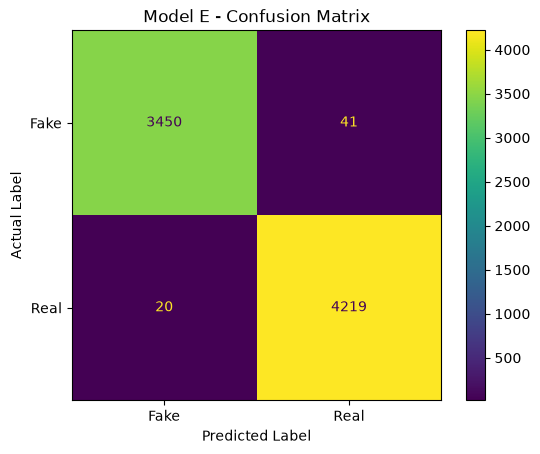

In [131]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("MODEL E CONFUSION MATRIX")
print("=" * 50)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_e,
    display_labels=["Fake", "Real"]
)

plt.title("Model E - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [132]:
print("=" * 65)
print("              FINAL PROJECT RESULTS")
print("=" * 65)

print("\nMODEL E")
print("-" * 65)

print(f"Accuracy :  {accuracy_e:.4f}")
print(f"Precision:  {precision_e:.4f}")
print(f"Recall   :  {recall_e:.4f}")
print(f"F1 Score :  {f1_e:.4f}")

print("\nIndian News Evaluation")
print("-" * 65)

print("Correct predictions: 4 / 5")
print("Evaluation accuracy: 80%")

print("\nWeb Verification")
print("-" * 65)

print("Web verification is performed for BOTH:")
print("  • ML = REAL")
print("  • ML = FAKE")

print("\nPossible final assessments:")
print("  • REAL — WEB SUPPORTED")
print("  • FAKE — WEB SUPPORTED")
print("  • MODEL/WEB CONFLICT")
print("  • INSUFFICIENT WEB EVIDENCE")

print("\n" + "=" * 65)

              FINAL PROJECT RESULTS

MODEL E
-----------------------------------------------------------------
Accuracy :  0.9921
Precision:  0.9904
Recall   :  0.9953
F1 Score :  0.9928

Indian News Evaluation
-----------------------------------------------------------------
Correct predictions: 4 / 5
Evaluation accuracy: 80%

Web Verification
-----------------------------------------------------------------
Web verification is performed for BOTH:
  • ML = REAL
  • ML = FAKE

Possible final assessments:
  • REAL — WEB SUPPORTED
  • FAKE — WEB SUPPORTED
  • MODEL/WEB CONFLICT
  • INSUFFICIENT WEB EVIDENCE



In [133]:
import joblib

# Save Model E
joblib.dump(
    model_e,
    "model_e.pkl"
)

# Save Model E TF-IDF vectorizer
joblib.dump(
    model_e_tfidf,
    "model_e_tfidf.pkl"
)

print("Model E saved successfully.")
print("TF-IDF vectorizer saved successfully.")

Model E saved successfully.
TF-IDF vectorizer saved successfully.


In [134]:
import os

print(os.path.exists(
    r"D:\python projects\fake news detector\model_e.pkl"
))

print(os.path.exists(
    r"D:\python projects\fake news detector\model_e_tfidf.pkl"
))

False
False
